# ДИ и стоимость

In [1]:
from pathlib import Path
import sqlite3

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

sns.set_theme(style='whitegrid', context='notebook')
pd.options.display.max_columns = 100
pd.options.display.float_format = lambda x: f'{x:,.2f}'.replace(',', ' ')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

HERE = Path.cwd().resolve()
if (HERE / 'backend').exists():
    ROOT = HERE
elif (HERE.parent / 'backend').exists():
    ROOT = HERE.parent
else:
    ROOT = Path('/Users/sergey/PycharmProjects/WB_hackaton')

DATA_DIR = ROOT / 'backend' / 'data'
TRASH_DIR = ROOT / 'trash'
TARGET_COL = 'target_2h'
RANDOM_STATE = 42
EDA_SAMPLE_N = 150_000

## Загрузка

In [2]:
di_df = pd.read_csv(TRASH_DIR / 'di_0_2h_large_sample.csv')
case_summary_df = pd.read_csv(TRASH_DIR / 'di_cost_compare_case_summary.csv')
scenario_summary_df = pd.read_csv(TRASH_DIR / 'di_cost_compare_scenario_summary.csv')

for col in ['timestamp', 'future_timestamp_0_2h']:
    di_df[col] = pd.to_datetime(di_df[col])
    case_summary_df[col] = pd.to_datetime(case_summary_df[col])

scenario_order = ['point_forecast', 'upper_ci', 'truth_oracle']
scenario_map = {
    'point_forecast': 'Точка прогноза',
    'upper_ci': 'Верхняя граница ДИ',
    'truth_oracle': 'Реальный спрос',
}

In [3]:
print('строк DI', f"{len(di_df):,}".replace(',', ' '))
print('кейсов cost', case_summary_df['sample_id'].nunique())
print('маршрутов DI', di_df['route_id'].nunique())
print('складов DI', di_df['warehouse_id'].nunique())

строк DI 10 011
кейсов cost 500
маршрутов DI 71
складов DI 15


## ДИ

In [4]:
valid_di = di_df[
    (di_df['prediction_status'] == 'ok')
    & di_df['pred_0_2h'].notna()
    & di_df['lower_0_2h'].notna()
    & di_df['upper_0_2h'].notna()
    & di_df['target_step_4_true'].notna()
].copy()

valid_di['err'] = valid_di['pred_0_2h'] - valid_di['target_step_4_true']
valid_di['abs_err'] = valid_di['err'].abs()
valid_di['sq_err'] = valid_di['err'] ** 2
valid_di['miss_type'] = np.select(
    [
        valid_di['target_step_4_true'] < valid_di['lower_0_2h'],
        valid_di['target_step_4_true'] > valid_di['upper_0_2h'],
    ],
    ['ниже', 'выше'],
    default='покрыт',
)

In [5]:
di_metrics = pd.DataFrame([
    {'метрика': 'coverage', 'значение': valid_di['covered_0_2h'].mean()},
    {'метрика': 'mae', 'значение': valid_di['abs_err'].mean()},
    {'метрика': 'rmse', 'значение': np.sqrt(valid_di['sq_err'].mean())},
    {'метрика': 'wape', 'значение': valid_di['abs_err'].sum() / valid_di['target_step_4_true'].sum()},
    {'метрика': 'mean width', 'значение': valid_di['interval_width_0_2h'].mean()},
    {'метрика': 'median width', 'значение': valid_di['interval_width_0_2h'].median()},
])
display(di_metrics)

,метрика,значение
0,coverage,0.88
1,mae,30.08
2,rmse,57.36
3,wape,0.39
4,mean width,111.41
5,median width,63.00


In [6]:
coverage_wh_df = (
    valid_di.groupby(['warehouse_id', 'warehouse_name'], dropna=False)['covered_0_2h']
    .mean()
    .mul(100)
    .reset_index(name='coverage_pct')
    .sort_values('coverage_pct', ascending=False)
)
display(coverage_wh_df)

,warehouse_id,warehouse_name,coverage_pct
1,w02,Подольск-1,93.19
13,w14,Саратов-1,91.91
6,w07,Урал-Хаб,91.35
8,w09,Ростов-Юг,91.13
7,w08,Самара-1,89.79
9,w10,Краснодар-1,89.79
4,w05,Казань-Логистик,89.36
0,w01,Москва-Восток,89.22
2,w03,Химки-Центр,88.79
10,w11,Воронеж-Центральный,87.66


In [7]:
miss_df = valid_di['miss_type'].value_counts(normalize=True).mul(100).rename_axis('type').reset_index(name='pct')
display(miss_df)

,type,pct
0,покрыт,88.24
1,выше,9.15
2,ниже,2.61


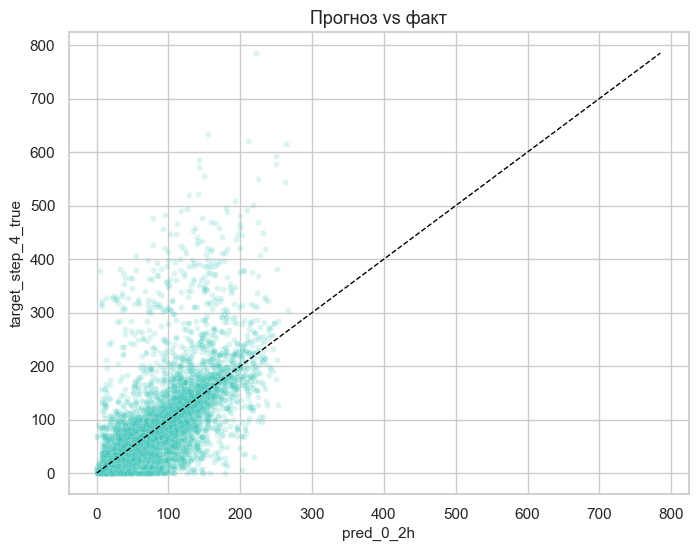

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=valid_di.sample(min(8000, len(valid_di)), random_state=RANDOM_STATE), x='pred_0_2h', y='target_step_4_true', alpha=0.18, s=18, color='#2EC4B6')
low = min(valid_di['pred_0_2h'].min(), valid_di['target_step_4_true'].min())
high = max(valid_di['pred_0_2h'].max(), valid_di['target_step_4_true'].max())
plt.plot([low, high], [low, high], linestyle='--', color='black', linewidth=1)
plt.title('Прогноз vs факт')
plt.xlabel('pred_0_2h')
plt.ylabel('target_step_4_true')
plt.show()

In [9]:
route_counts = (
    valid_di.groupby('route_id')['future_timestamp_0_2h']
    .nunique()
    .sort_values(ascending=False)
)
plot_routes = route_counts.head(3).index.astype(str).tolist()
plot_routes

['19', '624', '653']

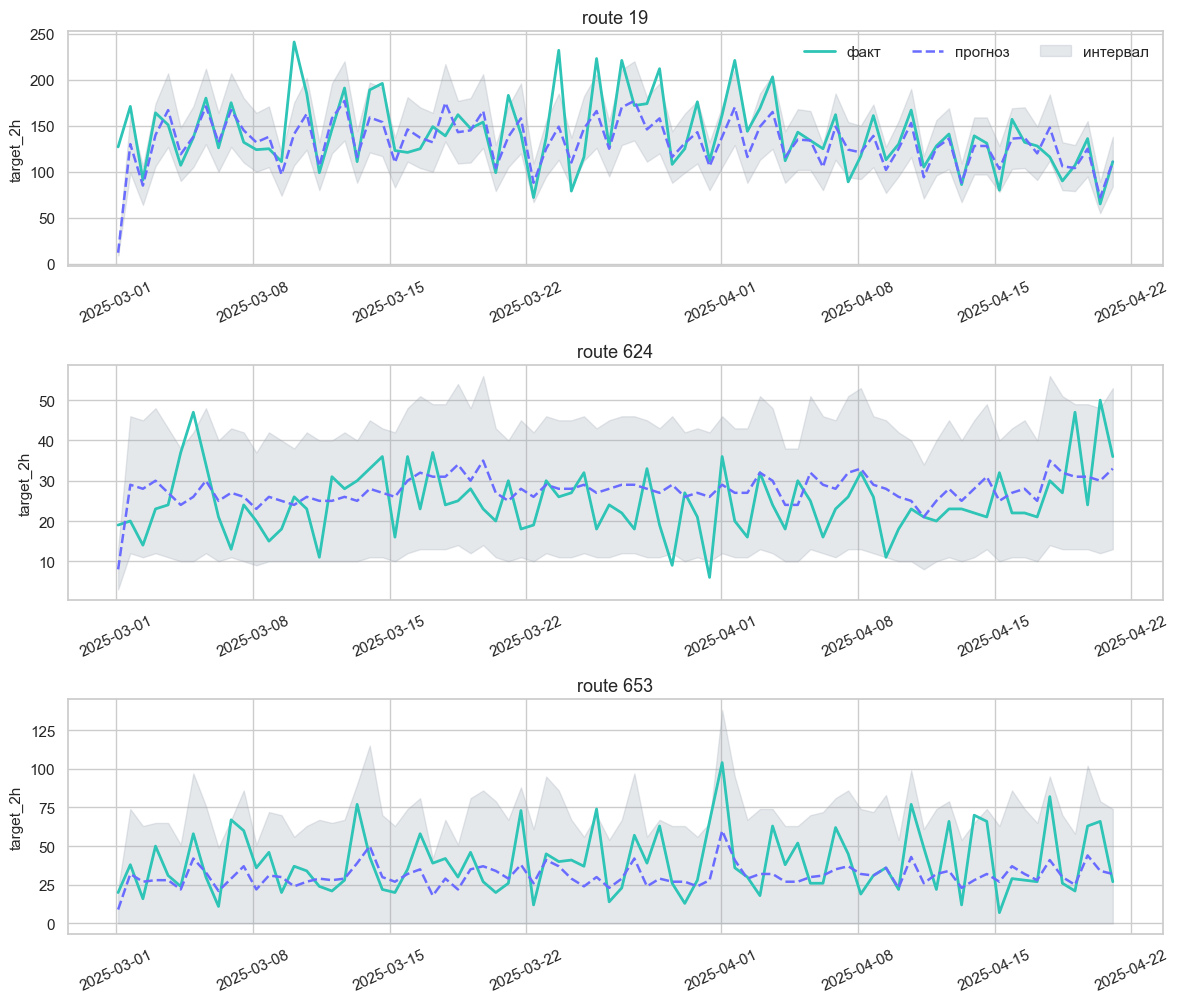

In [10]:
fig, axes = plt.subplots(len(plot_routes), 1, figsize=(12, 3.4 * len(plot_routes)), sharex=False)
if len(plot_routes) == 1:
    axes = [axes]

for ax, route_id in zip(axes, plot_routes):
    route_df = valid_di[valid_di['route_id'].astype(str) == route_id].sort_values('future_timestamp_0_2h').head(80)
    ax.plot(route_df['future_timestamp_0_2h'], route_df['target_step_4_true'], color='#2EC4B6', linewidth=2, label='факт')
    ax.plot(route_df['future_timestamp_0_2h'], route_df['pred_0_2h'], color='#6A6CFF', linewidth=1.8, linestyle='--', label='прогноз')
    ax.fill_between(route_df['future_timestamp_0_2h'], route_df['lower_0_2h'], route_df['upper_0_2h'], color='#9AA5B1', alpha=0.25, label='интервал')
    ax.set_title(f'route {route_id}')
    ax.set_ylabel('target_2h')
    ax.tick_params(axis='x', rotation=25)

axes[0].legend(frameon=False, ncol=3)
plt.tight_layout()
plt.show()

## Стоимость

In [11]:
scenario_summary_view = scenario_summary_df[['scenario', 'rows', 'mean_input_demand_0_2h', 'mean_b_cost_total', 'mean_empty_capacity']].copy()
scenario_summary_view['scenario'] = scenario_summary_view['scenario'].map(scenario_map)
display(scenario_summary_view)

,scenario,rows,mean_input_demand_0_2h,mean_b_cost_total,mean_empty_capacity
0,Точка прогноза,500,62.03,10 205.39,1.47
1,Реальный спрос,500,76.60,12 790.91,1.36
2,Верхняя граница ДИ,500,117.85,19 420.09,1.30


/Users/sergey/PycharmProjects/WB_hackaton/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


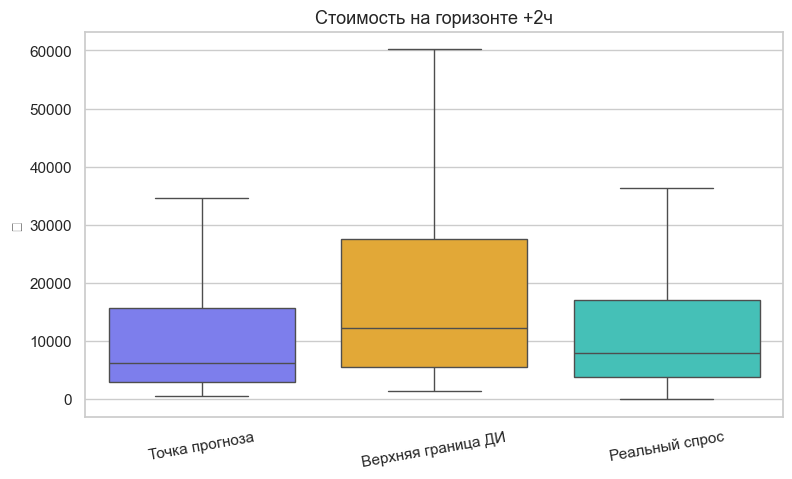

In [12]:
plot_cost_df = case_summary_df.copy()
plot_cost_df['scenario_label'] = plot_cost_df['scenario'].map(scenario_map)
order = [scenario_map[s] for s in scenario_order]

plt.figure(figsize=(9, 5))
sns.boxplot(
    data=plot_cost_df,
    x='scenario_label',
    y='b_cost_total',
    hue='scenario_label',
    order=order,
    hue_order=order,
    palette=['#6A6CFF', '#FFB11A', '#30D5C8'],
    showfliers=False,
    dodge=False,
)
plt.legend([], [], frameon=False)
plt.title('Стоимость на горизонте +2ч')
plt.xlabel('')
plt.ylabel('₽')
plt.xticks(rotation=10)
plt.show()

/Users/sergey/PycharmProjects/WB_hackaton/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


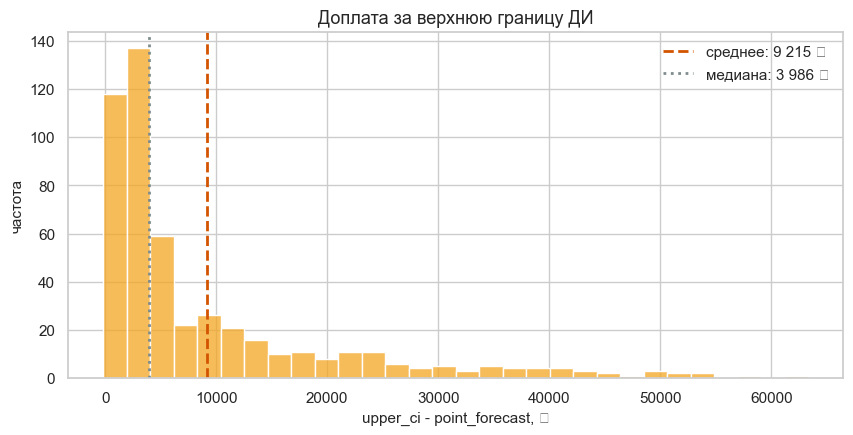

In [13]:
pivot_cost = (
    plot_cost_df.pivot_table(index='sample_id', columns='scenario', values='b_cost_total', aggfunc='first')
    .reindex(columns=scenario_order)
    .dropna()
)
delta_upper_vs_point = pivot_cost['upper_ci'] - pivot_cost['point_forecast']
mean_delta = delta_upper_vs_point.mean()
median_delta = delta_upper_vs_point.median()

plt.figure(figsize=(10, 4.5))
sns.histplot(delta_upper_vs_point, bins=30, color='#F5A623', edgecolor='white')
plt.axvline(mean_delta, color='#D35400', linestyle='--', linewidth=2, label=f'среднее: {mean_delta:,.0f} ₽'.replace(',', ' '))
plt.axvline(median_delta, color='#7F8C8D', linestyle=':', linewidth=2, label=f'медиана: {median_delta:,.0f} ₽'.replace(',', ' '))
plt.title('Доплата за верхнюю границу ДИ')
plt.xlabel('upper_ci - point_forecast, ₽')
plt.ylabel('частота')
plt.legend(frameon=False)
plt.show()

/var/folders/3_/tf8cx26n3p30t57pcfyv0d8w0000gn/T/ipykernel_8225/894520811.py:17: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/sergey/PycharmProjects/WB_hackaton/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


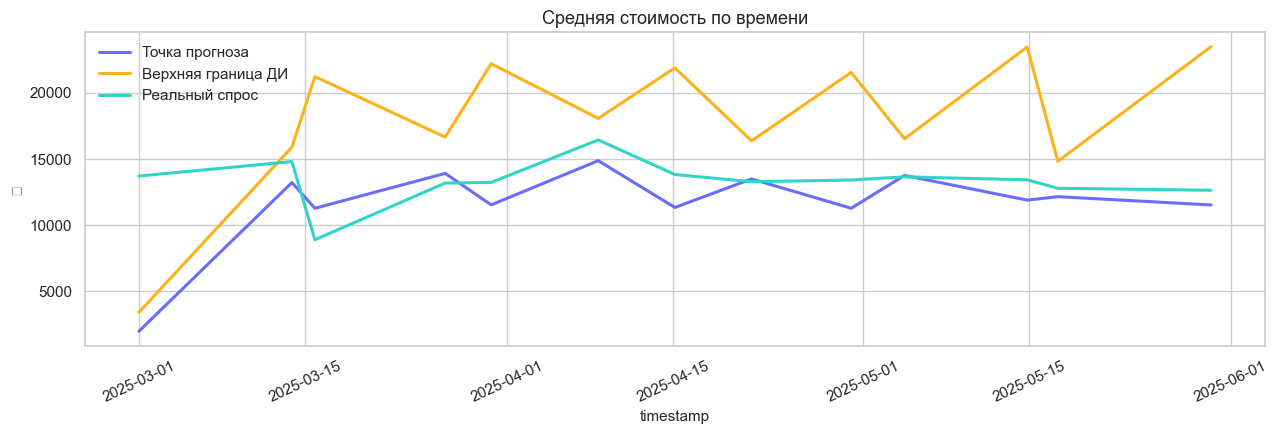

In [14]:
time_cost_df = (
    plot_cost_df.groupby(['timestamp', 'scenario'], dropna=False)['b_cost_total']
    .mean()
    .reset_index(name='mean_b_cost_total')
)

plt.figure(figsize=(13, 4.5))
for scenario, color in [('point_forecast', '#6A6CFF'), ('upper_ci', '#FFB11A'), ('truth_oracle', '#30D5C8')]:
    sub = time_cost_df[time_cost_df['scenario'] == scenario].sort_values('timestamp')
    plt.plot(sub['timestamp'], sub['mean_b_cost_total'], label=scenario_map[scenario], color=color, linewidth=2.2)

plt.title('Средняя стоимость по времени')
plt.xlabel('timestamp')
plt.ylabel('₽')
plt.legend(frameon=False)
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [15]:
veh_pivot = (
    case_summary_df.pivot_table(index='sample_id', columns='scenario', values='b_vehicles_count_total', aggfunc='first')
    .reindex(columns=scenario_order)
    .dropna()
)
veh_summary_df = pd.DataFrame([
    {'scenario': 'point_forecast', 'mean_vehicles': veh_pivot['point_forecast'].mean()},
    {'scenario': 'upper_ci', 'mean_vehicles': veh_pivot['upper_ci'].mean()},
    {'scenario': 'truth_oracle', 'mean_vehicles': veh_pivot['truth_oracle'].mean()},
])
veh_summary_df['scenario'] = veh_summary_df['scenario'].map(scenario_map)
display(veh_summary_df)

,scenario,mean_vehicles
0,Точка прогноза,4.14
1,Верхняя граница ДИ,7.47
2,Реальный спрос,5.00


/var/folders/3_/tf8cx26n3p30t57pcfyv0d8w0000gn/T/ipykernel_8225/3175938619.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=veh_summary_df, x='scenario', y='mean_vehicles', palette=['#6A6CFF', '#FFB11A', '#30D5C8'])


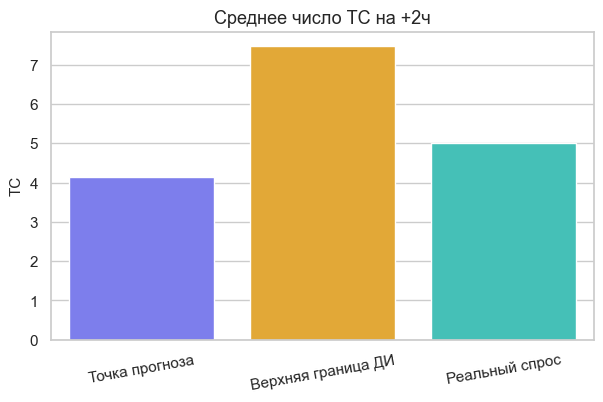

In [16]:
plt.figure(figsize=(7, 4))
sns.barplot(data=veh_summary_df, x='scenario', y='mean_vehicles', palette=['#6A6CFF', '#FFB11A', '#30D5C8'])
plt.title('Среднее число ТС на +2ч')
plt.xlabel('')
plt.ylabel('ТС')
plt.xticks(rotation=10)
plt.show()

In [17]:
cover_pivot = case_summary_df.pivot_table(
    index='sample_id',
    columns='scenario',
    values=['b_actually_shipped', 'source_true_0_2h'],
    aggfunc='first',
)
truth = cover_pivot['source_true_0_2h']['point_forecast']
point_cover = cover_pivot['b_actually_shipped']['point_forecast'] >= truth
upper_cover = cover_pivot['b_actually_shipped']['upper_ci'] >= truth
cover_summary_df = pd.DataFrame([
    {'метрика': 'точки хватило, %', 'значение': round(point_cover.mean() * 100, 2)},
    {'метрика': 'верхней границы хватило, %', 'значение': round(upper_cover.mean() * 100, 2)},
    {'метрика': 'ДИ закрыл там, где точка нет', 'значение': int((upper_cover & ~point_cover).sum())},
    {'метрика': 'доля таких кейсов, %', 'значение': round((upper_cover & ~point_cover).mean() * 100, 2)},
])
display(cover_summary_df)

,метрика,значение
0,"точки хватило, %",44.60
1,"верхней границы хватило, %",79.40
2,"ДИ закрыл там, где точка нет",174.00
3,"доля таких кейсов, %",34.80
